PCOS Detection - Exploratory Data Analysis

### 1. Setup and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# Enhanced plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)


# ignore warnings
import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv('../data/pcos_prediction_dataset.csv')
df.head()

,Country,Age,BMI,Menstrual Regularity,Hirsutism,Acne Severity,Family History of PCOS,Insulin Resistance,Lifestyle Score,Stress Levels,Urban/Rural,Socioeconomic Status,Awareness of PCOS,Fertility Concerns,Undiagnosed PCOS Likelihood,Ethnicity,Diagnosis
0,Madagascar,26,Overweight,Regular,Yes,Severe,Yes,Yes,2,Low,Rural,High,Yes,No,0.11,Hispanic,Yes
1,Vietnam,16,Underweight,Regular,Yes,NaN,No,Yes,4,High,Rural,Middle,Yes,No,0.16,Other,No
2,Somalia,41,Normal,Regular,No,Moderate,No,No,7,Medium,Urban,Middle,Yes,Yes,0.20,Other,No
3,Malawi,27,Normal,Irregular,No,Mild,No,No,10,Low,Urban,High,Yes,No,0.07,Caucasian,Yes
4,France,26,Overweight,Irregular,Yes,NaN,No,No,7,Medium,Urban,Middle,No,No,0.23,Caucasian,No


In [3]:
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

In [4]:
# impute missing values

# Get the mode (most frequent value). mode() returns a Series, so we take the first element
mode_value = df['acne_severity'].mode()[0]

# Fill NaNs with that mode
df['acne_severity'] = df['acne_severity'].fillna(mode_value)

### 2. Visualization 1: Target Distribution (Class imbalanc)

Purpose : Understand the diagnosis rate and imbalance


Business Question: How imbalanced is our PCOS detection problem?

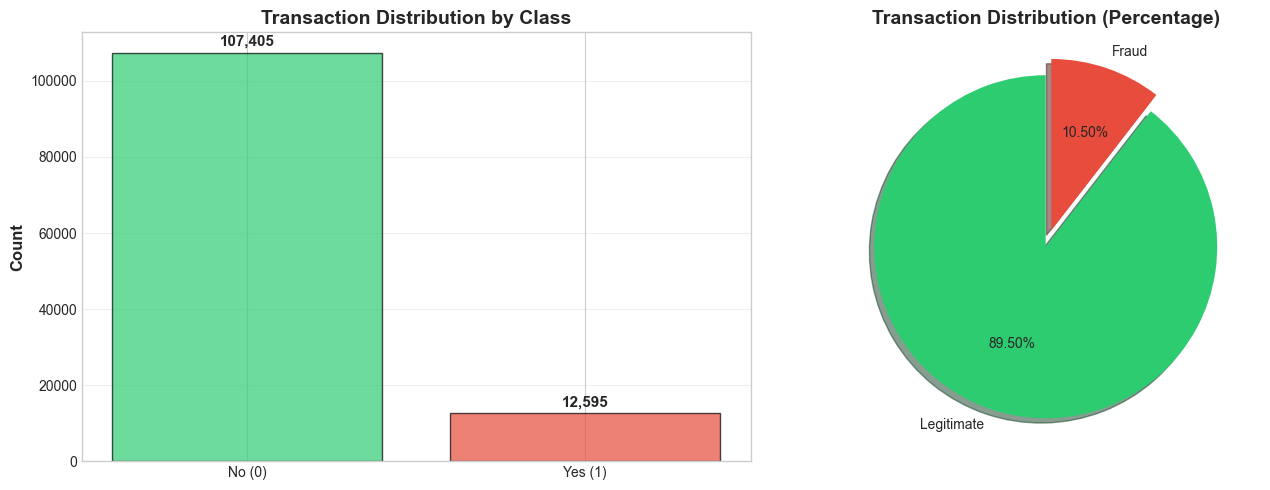


💡 BUSINESS INSIGHTS: Class Imbalance

📊 Fraud Rate: 10.50%
   - Out of every 1,000 diagnosis, ~104 are diagnosis

⚖️  Imbalance Ratio: 8.5:1 (Yes:No)
   - For every 1 fraudulent transaction, there are 8 diagnosis ones

⚠️  Modeling Implications:
   ❌ Accuracy is NOT appropriate (would be ~89.5% by predicting all positive dignosis)
   ✓ Use F1-score as primary metric
   ✓ Use stratified splits (StratifiedKFold, stratify=y)
   ✓ Consider class_weight='balanced' or SMOTE

💼 Business Impact:
   - False Negatives (missed fraud): Direct financial loss
   - False Positives (blocking legit): Customer frustration, lost sales
   - Need to balance precision and recall based on business costs


In [5]:
target_col = 'diagnosis'
if target_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Count plot
    diagnosis_counts = df[target_col].value_counts().sort_index()
    colors = ['#2ecc71', '#e74c3c']  # Green for legit, red for fraud
    
    axes[0].bar(['No (0)', 'Yes (1)'], diagnosis_counts.values, color=colors, alpha=0.7, edgecolor='black')
    axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
    axes[0].set_title('Transaction Distribution by Class', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(diagnosis_counts.values):
        axes[0].text(i, v + max(diagnosis_counts) * 0.01, f'{v:,}', 
                    ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Pie chart
    diagnosis_pct = df[target_col].value_counts(normalize=True) * 100
    axes[1].pie(diagnosis_pct.values, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%',
               colors=colors, startangle=90, explode=[0, 0.1], shadow=True)
    axes[1].set_title('Transaction Distribution (Percentage)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Business insights
    diagnosis_rate = diagnosis_pct.iloc[1]
    imbalance_ratio = diagnosis_counts.iloc[0] / diagnosis_counts.iloc[1]
    
    print("\n" + "="*60)
    print("💡 BUSINESS INSIGHTS: Class Imbalance")
    print("="*60)
    print(f"\n📊 Fraud Rate: {diagnosis_rate:.2f}%")
    print(f"   - Out of every 1,000 diagnosis, ~{int(diagnosis_rate * 10)} are diagnosis")
    print(f"\n⚖️  Imbalance Ratio: {imbalance_ratio:.1f}:1 (Yes:No)")
    print(f"   - For every 1 fraudulent transaction, there are {int(imbalance_ratio)} diagnosis ones")
    print(f"\n⚠️  Modeling Implications:")
    print(f"   ❌ Accuracy is NOT appropriate (would be ~{100-diagnosis_rate:.1f}% by predicting all positive dignosis)")
    print(f"   ✓ Use F1-score as primary metric")
    print(f"   ✓ Use stratified splits (StratifiedKFold, stratify=y)")
    print(f"   ✓ Consider class_weight='balanced' or SMOTE")
    print(f"\n💼 Business Impact:")
    print(f"   - False Negatives (missed fraud): Direct financial loss")
    print(f"   - False Positives (blocking legit): Customer frustration, lost sales")
    print(f"   - Need to balance precision and recall based on business costs")
else:
    print("⚠ Target column not found. Cannot create visualization.")


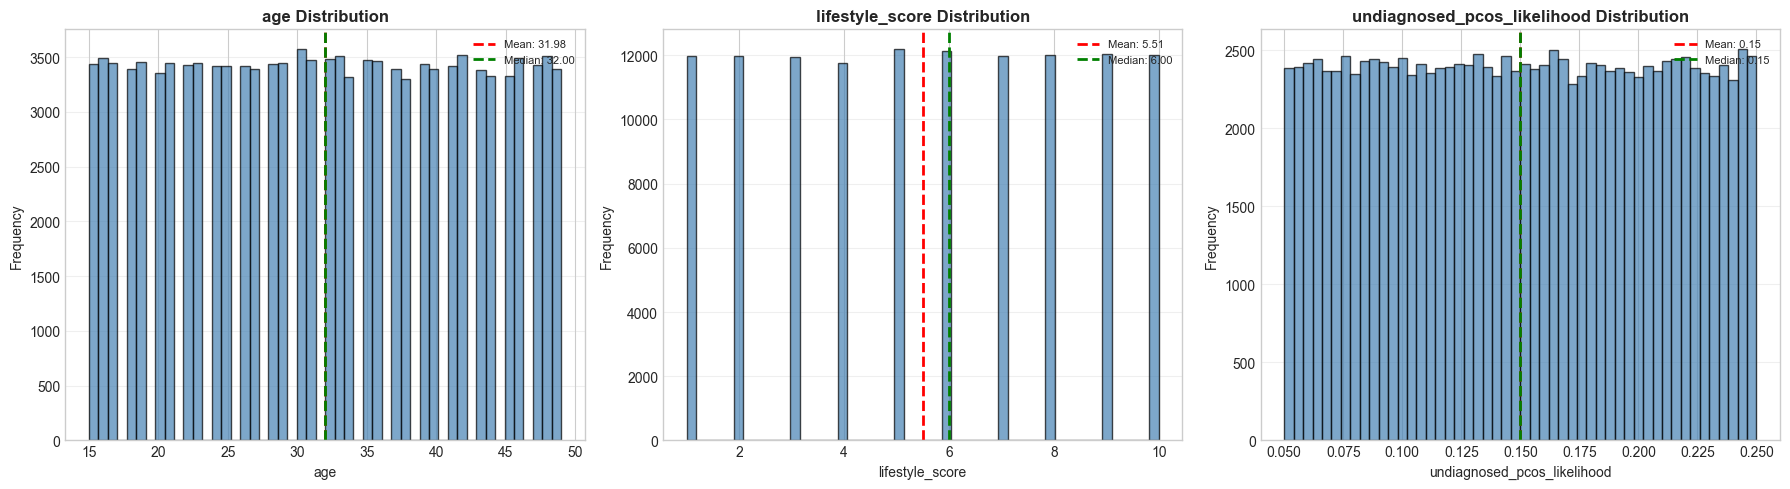

In [6]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.to_list()

# Plot distributions for top numerical features
n_features = min(3, len(numerical_cols))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# If only one plot exists, make axes iterable
if n_features == 1:
    axes = [axes]

for i, col in enumerate(numerical_cols[:n_features]):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

    # Add statistics
    mean_val = df[col].mean()
    median_val = df[col].median()

    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2,
                    label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2,
                    label=f'Median: {median_val:.2f}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

* Data distribution is standard.

In [7]:
df[target_col] = df[target_col].map({'No': 0, 'Yes': 1})

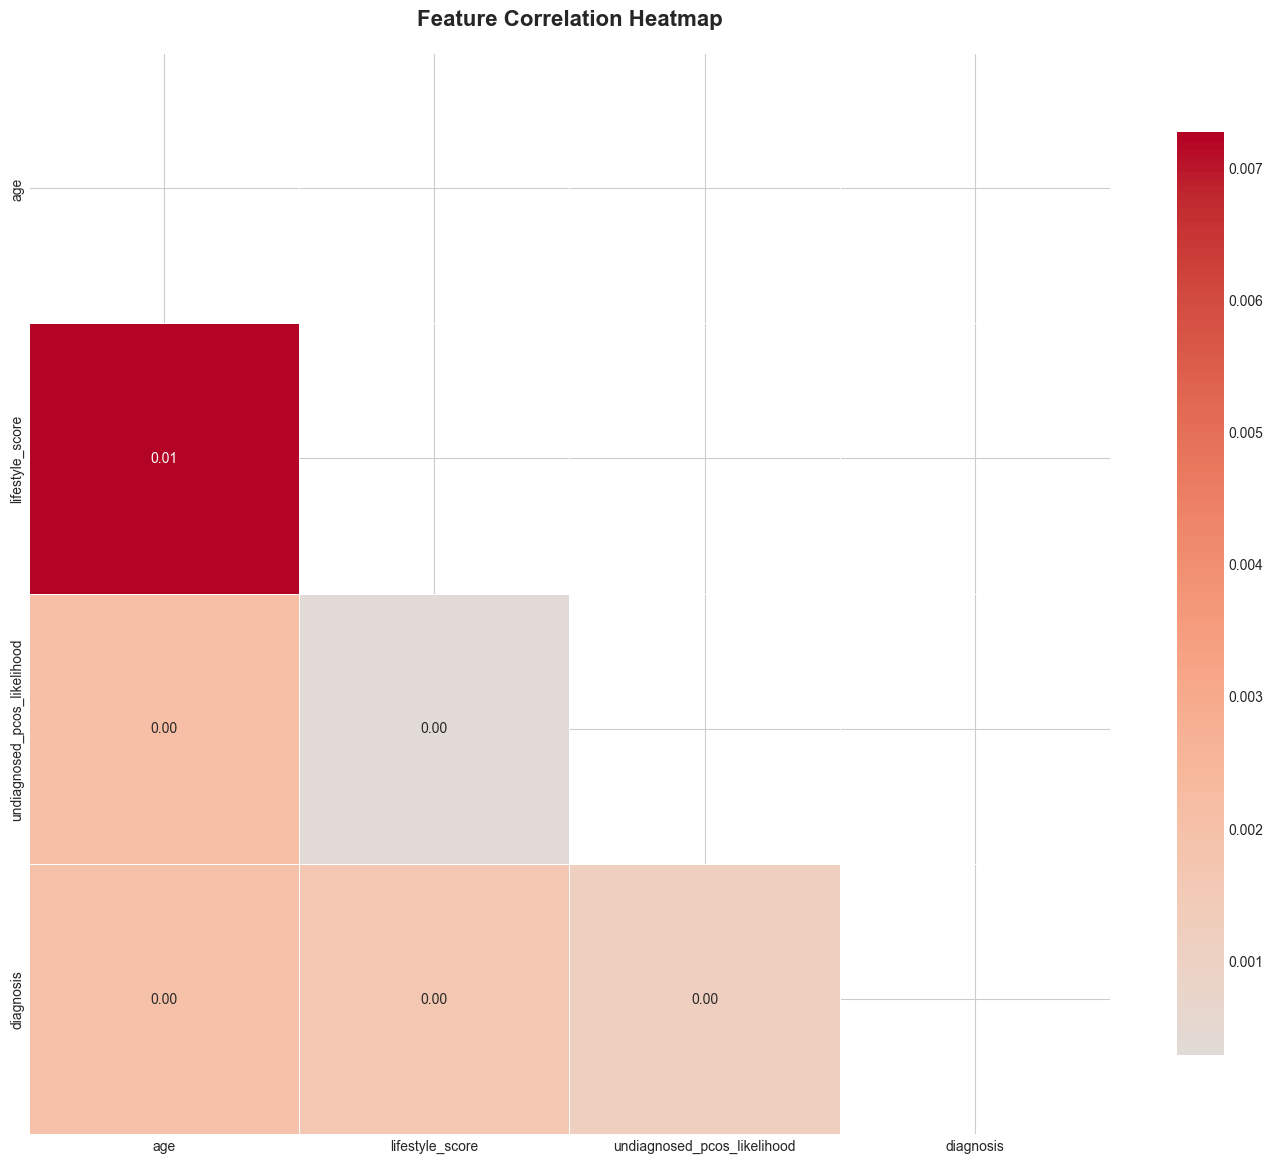


💡 BUSINESS INSIGHTS: Feature Correlations with diagnosis

📈 Top 5 Positive Correlations (fraud indicators):
age                            1.99e-03
lifestyle_score                1.68e-03
undiagnosed_pcos_likelihood    1.21e-03
Name: diagnosis, dtype: float64

📉 Top 5 Negative Correlations (legitimacy indicators):
age                            1.99e-03
lifestyle_score                1.68e-03
undiagnosed_pcos_likelihood    1.21e-03
Name: diagnosis, dtype: float64

⚠️  Multicollinearity Check:
   ✓ No severe multicollinearity detected (|corr| < 0.8)

💼 Business Implications:
   - Features with high correlation to fraud are key fraud indicators
   - Monitor these features closely in production
   - Use for fraud detection rules and alerts


In [8]:
# Select numerical features for correlation
corr_features = numerical_cols[:15]  # Top 15 to keep heatmap readable
if target_col:
    corr_features.append(target_col)

# Compute correlation matrix
corr_matrix = df[corr_features].corr()

# Create heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Find strong correlations
if target_col:
    target_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
    print("\n" + "="*60)
    print(f"💡 BUSINESS INSIGHTS: Feature Correlations with {target_col}")
    print("="*60)
    print(f"\n📈 Top 5 Positive Correlations (fraud indicators):")
    print(target_corr.head())
    print(f"\n📉 Top 5 Negative Correlations (legitimacy indicators):")
    print(target_corr.tail())
    print(f"\n⚠️  Multicollinearity Check:")
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.8:
                high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
    
    if high_corr:
        print(f"   Found {len(high_corr)} feature pairs with |correlation| > 0.8:")
        for feat1, feat2, corr in high_corr[:5]:
            print(f"   - {feat1} ↔ {feat2}: {corr:.2f}")
        print("   ⚠ Consider removing one from each pair to reduce multicollinearity")
    else:
        print("   ✓ No severe multicollinearity detected (|corr| < 0.8)")
    
    print(f"\n💼 Business Implications:")
    print("   - Features with high correlation to fraud are key fraud indicators")
    print("   - Monitor these features closely in production")
    print("   - Use for fraud detection rules and alerts")

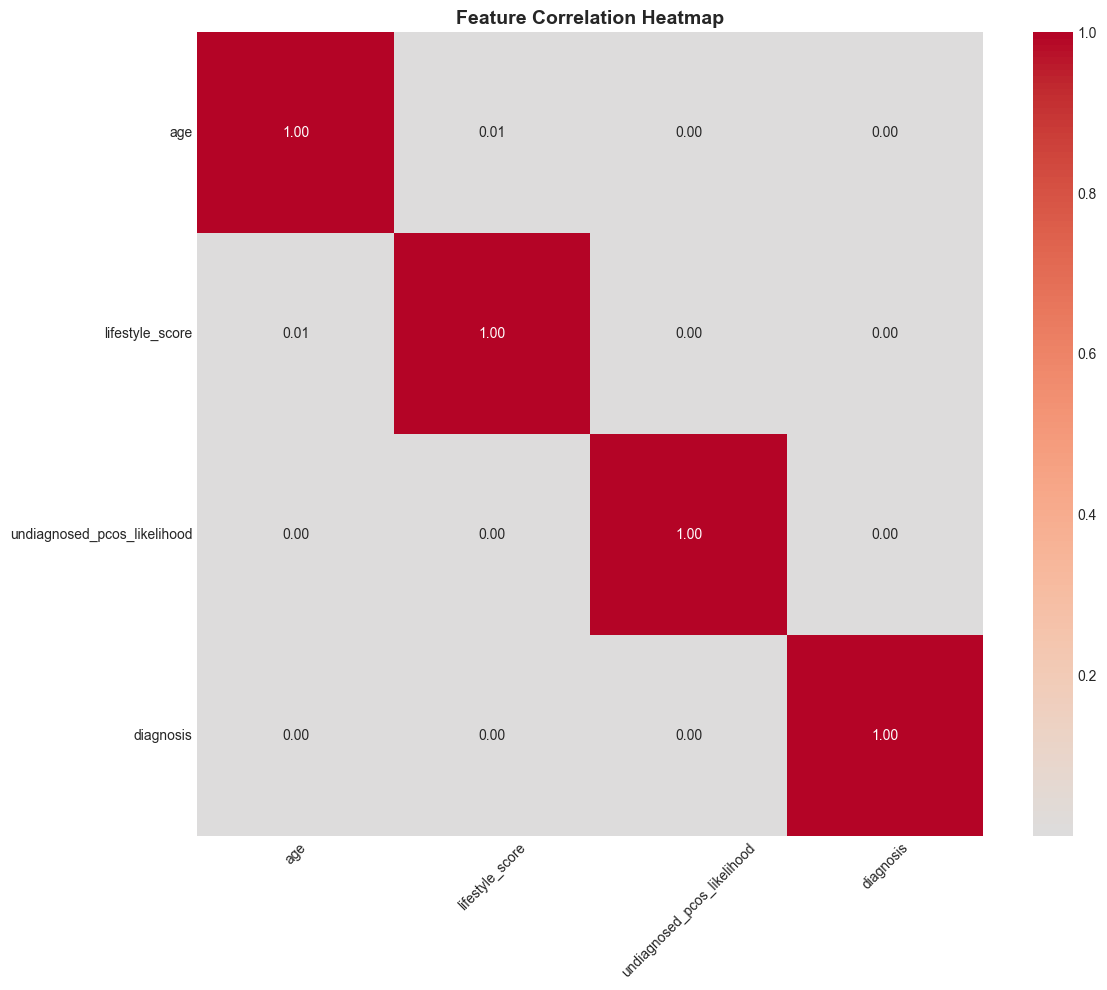

In [9]:
# Select numerical features + target
corr_features = numerical_cols + [target_col]

# Compute correlation matrix
corr_matrix = df[corr_features].corr()

# Simple heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
# Select all object/categorical columns
categorical_cols = df.select_dtypes(include=['string', 'category']).columns.to_list()
categorical_cols

['country',
 'bmi',
 'menstrual_regularity',
 'hirsutism',
 'acne_severity',
 'family_history_of_pcos',
 'insulin_resistance',
 'stress_levels',
 'urban/rural',
 'socioeconomic_status',
 'awareness_of_pcos',
 'fertility_concerns',
 'ethnicity']

### Target Rate Analysis

In [11]:
for col in categorical_cols:
    rates = df.groupby(col)[target_col].mean() * 100
    counts = df[col].value_counts()
    print(f"\nFeature: {col}")
    print(pd.DataFrame({"Count": counts, "Diagnosis Rate (%)": rates.round(2)}).sort_values("Diagnosis Rate (%)", ascending=False))


Feature: country
            Count  Diagnosis Rate (%)
country                              
Kenya        1591               12.70
Australia    1526               12.19
Syria        1517               11.80
Spain        1598               11.76
Somalia      1545               11.72
...           ...                 ...
Malawi       1632                9.31
Nepal        1509                9.28
Uzbekistan   1549                9.10
Iraq         1532                9.01
Senegal      1592                8.10

[77 rows x 2 columns]

Feature: bmi
             Count  Diagnosis Rate (%)
bmi                                   
Underweight   5937               11.32
Normal       60080               10.47
Overweight   36038               10.45
Obese        17945               10.40

Feature: menstrual_regularity
                      Count  Diagnosis Rate (%)
menstrual_regularity                           
Irregular             36059               10.60
Regular               83941               

### Chi-Square Test – to check statistical association:

In [12]:
from scipy.stats import chi2_contingency

for col in categorical_cols:
    contingency = pd.crosstab(df[col], df[target_col])
    chi2, p, dof, ex = chi2_contingency(contingency)
    print(f"{col}: chi2={chi2:.2f}, p-value={p:.4f}")

country: chi2=84.61, p-value=0.2336
bmi: chi2=4.59, p-value=0.2047
menstrual_regularity: chi2=0.60, p-value=0.4373
hirsutism: chi2=0.14, p-value=0.7064
acne_severity: chi2=0.09, p-value=0.9583
family_history_of_pcos: chi2=0.49, p-value=0.4838
insulin_resistance: chi2=1.43, p-value=0.2310
stress_levels: chi2=0.24, p-value=0.8859
urban/rural: chi2=0.22, p-value=0.6368
socioeconomic_status: chi2=7.62, p-value=0.0221
awareness_of_pcos: chi2=1.16, p-value=0.2813
fertility_concerns: chi2=1.24, p-value=0.2646
ethnicity: chi2=6.45, p-value=0.1681


* Most categorical features do not show a statistically significant association with the target (Diagnosis) at the 0.05 level:
* All columns have p-values > 0.05, indicating weak or no evidence of dependence on diagnosis.
* Only Socioeconomic Status shows a weak association with Diagnosis: chi2 = 7.62, p-value = 0.0221 (<0.05)
* Suggests that diagnosis rates slightly differ across socioeconomic levels.

In [13]:
# Map target to 0/1 and drop rows with missing target
df_clean = df.dropna(subset=[target_col]).copy()
y = df_clean["diagnosis"]

In [14]:
y

0         1
1         0
2         0
3         1
4         0
         ..
119995    0
119996    0
119997    1
119998    0
119999    0
Name: diagnosis, Length: 120000, dtype: int64

In [15]:
#X = pd.get_dummies(df_clean[categorical_cols], drop_first=True)

In [16]:
#from sklearn.feature_selection import mutual_info_classif

#mi = mutual_info_classif(X, y, discrete_features=True)
#mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
#print(mi_series.head(10))

In [17]:
#mi_series.head(15).sort_values().plot(kind='barh', figsize=(10,6), color='crimson')
#plt.xlabel('Mutual Information with Diagnosis')
#plt.title('Top Categorical Features by Mutual Information')
#plt.show()

### Prepare for Train-Test_split

In [18]:
from sklearn.feature_extraction import DictVectorizer

# Combine features (numerical + categorical)
features = df.drop(columns=[target_col])
# Convert dataframe to list of dicts
feature_dicts = features.to_dict(orient='records')

In [19]:
dv = DictVectorizer(sparse=False)  # sparse=True if you have very high-cardinality features
X = dv.fit_transform(feature_dicts)

print("Feature names:", dv.get_feature_names_out()[:10])
print("X shape:", X.shape)

Feature names: ['acne_severity=Mild' 'acne_severity=Moderate' 'acne_severity=Severe'
 'age' 'awareness_of_pcos=No' 'awareness_of_pcos=Yes' 'bmi=Normal'
 'bmi=Obese' 'bmi=Overweight' 'bmi=Underweight']
X shape: (120000, 112)


In [20]:
y = df[target_col]
y

0         1
1         0
2         0
3         1
4         0
         ..
119995    0
119996    0
119997    1
119998    0
119999    0
Name: diagnosis, Length: 120000, dtype: int64

In [21]:
features = df.drop(columns=[target_col])  # still a DataFrame
features.isnull().sum()

country                        0
age                            0
bmi                            0
menstrual_regularity           0
hirsutism                      0
acne_severity                  0
family_history_of_pcos         0
insulin_resistance             0
lifestyle_score                0
stress_levels                  0
urban/rural                    0
socioeconomic_status           0
awareness_of_pcos              0
fertility_concerns             0
undiagnosed_pcos_likelihood    0
ethnicity                      0
dtype: int64

In [22]:
from sklearn.model_selection import train_test_split

# Step 1: Split off test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Split remaining data into train (60%) and validation (20%))
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

# Check shapes
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (72000, 112) (72000,)
Validation shape: (24000, 112) (24000,)
Test shape: (24000, 112) (24000,)


* Stratify each split so that the diagnosis class imbalance is maintained across train/val/test.

### Encode features

In [23]:
# Combine numerical + categorical features
features = df_clean.drop(columns=[target_col])
X_train_dict = X_train.to_dict(orient='records')
X_val_dict = X_val.to_dict(orient='records')
X_test_dict = X_test.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train_enc = dv.fit_transform(X_train_dict)
X_val_enc = dv.transform(X_val_dict)
X_test_enc = dv.transform(X_test_dict)

AttributeError: 'numpy.ndarray' object has no attribute 'to_dict'